# Hackology II — Data Exploration

Ten notebook pokazuje jak załadować dataset, obejrzeć próbki i policzyć statystyki.

**Wymagania:** uruchom najpierw `./download_data.sh` aby pobrać dane.

In [3]:
import json
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

## 1. Załaduj anotacje

In [4]:
# Dane są w repo root/data/ — notebook jest w notebooks/ więc ścieżka jest ../data
DATA_DIR = Path("../data")
ANNOTATIONS_FILE = DATA_DIR / "train" / "annotations.json"

with open(ANNOTATIONS_FILE) as f:
    coco = json.load(f)

print(f"Images:      {len(coco['images'])}")
print(f"Annotations: {len(coco['annotations'])}")
print(f"Categories:  {len(coco['categories'])}")

Images:      3904
Annotations: 177128
Categories:  369


## 2. Rozkład kategorii

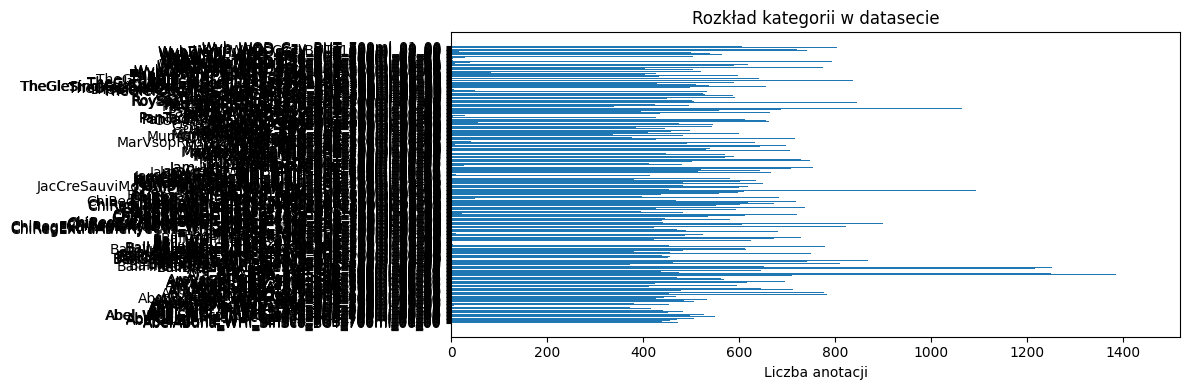

In [5]:
from typing import Any


cat_names = {c['id']: c['name'] for c in coco['categories']}
cat_counts = Counter[Any](ann['category_id'] for ann in coco['annotations'])

names = [cat_names[cid] for cid in sorted(cat_counts.keys())]
counts = [cat_counts[cid] for cid in sorted(cat_counts.keys())]

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(names, counts)
ax.set_xlabel("Liczba anotacji")
ax.set_title("Rozkład kategorii w datasecie")
plt.tight_layout()
plt.show()

## 3. Liczba bbox per obraz

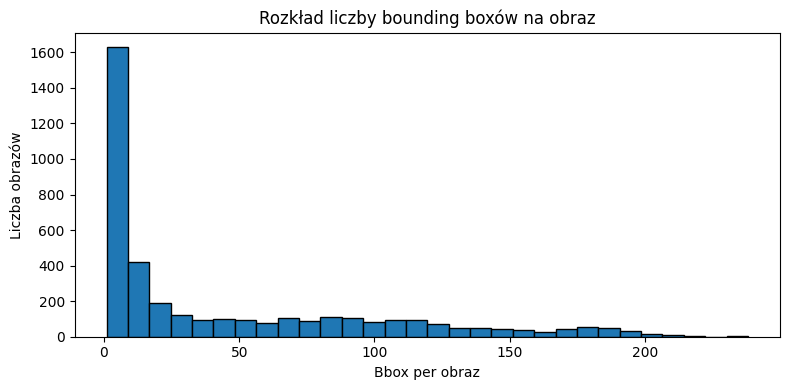

Min: 1, Max: 238, Mean: 45.4


In [6]:
bbox_per_img = Counter(ann['image_id'] for ann in coco['annotations'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bbox_per_img.values(), bins=30, edgecolor='black')
ax.set_xlabel("Bbox per obraz")
ax.set_ylabel("Liczba obrazów")
ax.set_title("Rozkład liczby bounding boxów na obraz")
plt.tight_layout()
plt.show()

print(f"Min: {min(bbox_per_img.values())}, Max: {max(bbox_per_img.values())}, "
      f"Mean: {sum(bbox_per_img.values()) / len(bbox_per_img):.1f}")

## 4. Wizualizacja przykładowego obrazu

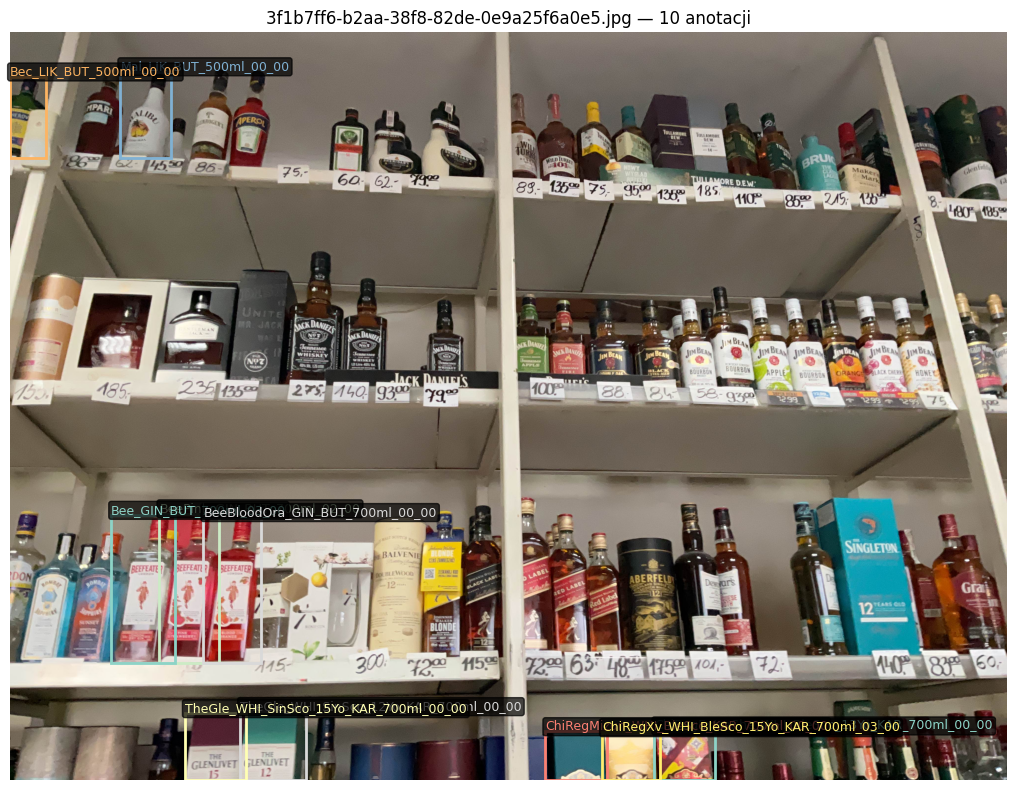

In [30]:
# Pokaż pierwszy obraz z anotacjami
img_info = coco['images'][4]
img_path = DATA_DIR / "train" / "images" / img_info['file_name']

anns = [a for a in coco['annotations'] if a['image_id'] == img_info['id']]

fig, ax = plt.subplots(1, figsize=(12, 8))
img = Image.open(img_path)
ax.imshow(img)

colors = plt.cm.Set3.colors
for ann in anns:
    x, y, w, h = ann['bbox']
    cat_name = cat_names[ann['category_id']]
    color = colors[ann['category_id'] % len(colors)]
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 5, cat_name, fontsize=9, color=color,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

ax.set_title(f"{img_info['file_name']} — {len(anns)} anotacji")
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Rozmiary bounding boxów

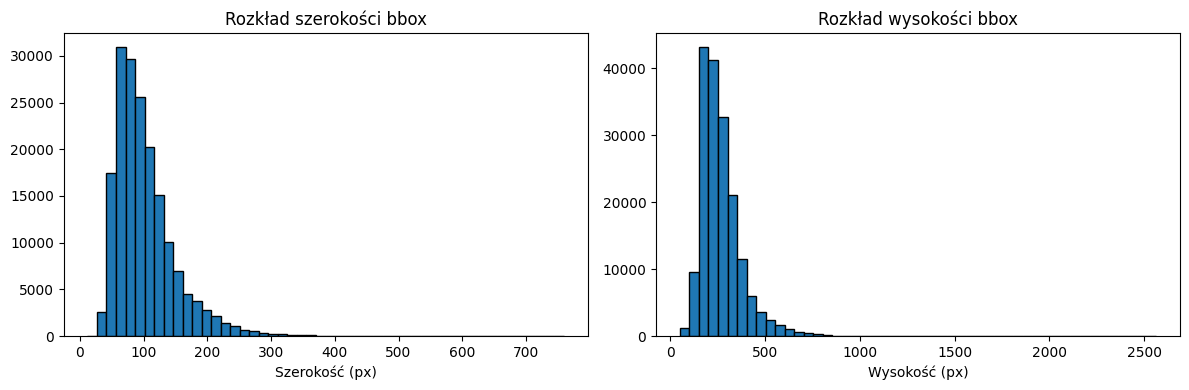

In [8]:
widths = [a['bbox'][2] for a in coco['annotations']]
heights = [a['bbox'][3] for a in coco['annotations']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=50, edgecolor='black')
axes[0].set_title('Rozkład szerokości bbox')
axes[0].set_xlabel('Szerokość (px)')

axes[1].hist(heights, bins=50, edgecolor='black')
axes[1].set_title('Rozkład wysokości bbox')
axes[1].set_xlabel('Wysokość (px)')

plt.tight_layout()
plt.show()

## 6. Sprawdź taxonomy.json

In [9]:
taxonomy = json.loads(Path('../taxonomy.json').read_text())
print("Kategorie w taxonomy.json:")
for cat in taxonomy['categories']:
    count = cat_counts.get(cat['id'], 0)
    print(f"  {cat['id']:3d}: {cat['name']:<30s} ({count} anotacji)")

Kategorie w taxonomy.json:
    1: AbelAbuna_WHI_SinSco_BUT_700ml_00_00 (472 anotacji)
    2: AbelAbuna_WHI_SinSco_BUT_700ml_01_00 (439 anotacji)
    3: AbelAbuna_WHI_SinSco_TUB_700ml_00_00 (443 anotacji)
    4: AbelAbuna_WHI_SinSco_TUB_700ml_01_00 (456 anotacji)
    5: AbelCasgAnn_WHI_SinSco_BUT_700ml_00_00 (470 anotacji)
    6: AbelCasgAnn_WHI_SinSco_BUT_700ml_01_00 (505 anotacji)
    7: AbelCasgAnn_WHI_SinSco_TUB_700ml_00_00 (462 anotacji)
    8: AbelCasgAnn_WHI_SinSco_TUB_700ml_01_00 (450 anotacji)
    9: Abel_WHI_SinSco_12Yo_BUT_700ml_00_00 (549 anotacji)
   10: Abel_WHI_SinSco_12Yo_BUT_700ml_01_00 (498 anotacji)
   11: Abel_WHI_SinSco_12Yo_KAR_2SZK_700ml_00_00 (526 anotacji)
   12: Abel_WHI_SinSco_12Yo_KAR_2SZK_700ml_01_00 (586 anotacji)
   13: Abel_WHI_SinSco_12Yo_TUB_700ml_00_00 (534 anotacji)
   14: Abel_WHI_SinSco_12Yo_TUB_700ml_01_00 (451 anotacji)
   15: Abel_WHI_SinSco_14Yo_BUT_700ml_00_00 (483 anotacji)
   16: Abel_WHI_SinSco_14Yo_TUB_700ml_00_00 (441 anotacji)
   17: Abel

In [10]:
coco['images'][0]


{'id': 1406,
 'file_name': '479e1350-5537-3aa7-8db6-1966856b6893.jpg',
 'width': 4032,
 'height': 3024,
 'source_dataset': 'DPR_MIR_3963_QUALITY_EVALUATION_09072025'}

In [11]:
coco['images'][1]

{'id': 1407,
 'file_name': 'b140cfa4-7215-3fe8-93db-e98ae56d858a.jpg',
 'width': 4032,
 'height': 3024,
 'source_dataset': 'DPR_MIR_3963_QUALITY_EVALUATION_09072025'}

In [19]:
coco['annotations'][0]

{'id': 26001,
 'image_id': 1406,
 'category_id': 216,
 'bbox': [3800, 1485, 231, 540],
 'area': 124740,
 'iscrowd': 0}

In [25]:
from collections import Counter

images = coco["images"]
Counter(img["source_dataset"] for img in images)

Counter({'SIDG_TRAIN': 1453,
         'SIDG_SYNTH_TRAIN': 1328,
         'DPR_MIR_3963_QUALITY_EVALUATION_09072025': 1123})